In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [2]:
BASE_PATH = "/kaggle/input/datasets/vincemarcs/mvsamultiple/MVSA"
DATA_PATH = os.path.join(BASE_PATH, "data")
LABEL_FILE = os.path.join(BASE_PATH, "labelResultAll.txt")

print(os.listdir(BASE_PATH))

['data', 'labelResultAll.txt']


In [3]:
data = []

with open(LABEL_FILE, "r", encoding="utf-8") as f:
    next(f)

    for line in f:
        parts = line.strip().split("\t")

        if len(parts) < 4:
            continue

        idx = parts[0]

        text_labels = []
        for vote in parts[1:4]:
            text_sent = vote.split(",")[0]
            text_labels.append(text_sent)

        majority = Counter(text_labels).most_common(1)[0][0]

        if majority == "neutral":
            continue

        binary_label = 0 if majority == "positive" else 1

        text_path = os.path.join(DATA_PATH, f"{idx}.txt")
        image_path = os.path.join(DATA_PATH, f"{idx}.jpg")

        if not os.path.exists(text_path) or not os.path.exists(image_path):
            continue

        with open(text_path, "r", encoding="utf-8") as tf:
            text = tf.read().strip()

        data.append([text, image_path, binary_label])

df = pd.DataFrame(data, columns=["text","image_path","label"])
df.to_csv("labeled.csv",index=False)

print("Dataset size:", len(df))
df.head()

Dataset size: 11902


,text,image_path,label
0,Knocked doors with the venerable #TeamTrudeau ...,/kaggle/input/datasets/vincemarcs/mvsamultiple...,0
1,An NPD gov't would institutionalize mediocrity...,/kaggle/input/datasets/vincemarcs/mvsamultiple...,1
2,"""""I think it's time for change"""" - Ana Commit ...",/kaggle/input/datasets/vincemarcs/mvsamultiple...,0
3,The Past and Future of the Refugee Crisis - Th...,/kaggle/input/datasets/vincemarcs/mvsamultiple...,0
4,Rdy to watch @ThomasMulcair rock it tnight in ...,/kaggle/input/datasets/vincemarcs/mvsamultiple...,0


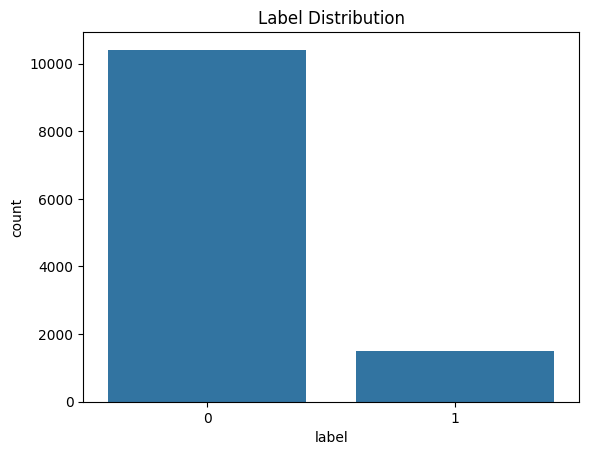

label
0    10411
1     1491
Name: count, dtype: int64


In [4]:
sns.countplot(x=df["label"])
plt.title("Label Distribution")
plt.show()

print(df["label"].value_counts())

Average text length: 87.28575029406822


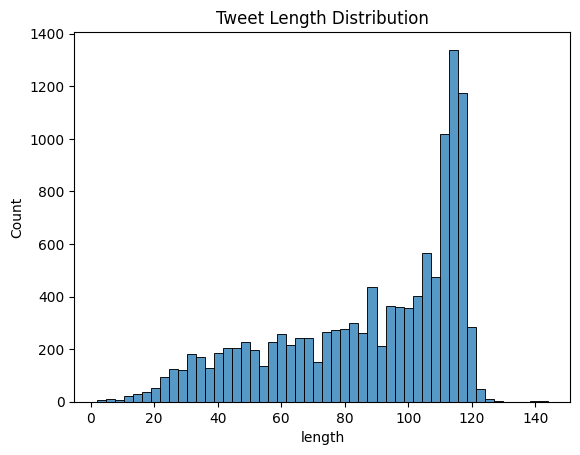

In [5]:
df["length"] = df["text"].apply(len)

print("Average text length:", df["length"].mean())

sns.histplot(df["length"], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

In [6]:
def extract_hashtags(text):
    return re.findall(r"#\w+", text)

all_tags = []

for t in df["text"]:
    all_tags.extend(extract_hashtags(t))

tag_counts = Counter(all_tags)

print("Top hashtags:", tag_counts.most_common(10))

Top hashtags: [('#Toronto', 769), ('#NationalDogDay', 723), ('#ShesKindaHotVMA', 563), ('#elxn42', 547), ('#yyc', 529), ('#cdnpoli', 452), ('#yeg', 399), ('#HamOnt', 391), ('#TIFF15', 361), ('#Canada', 335)]
